In [ ]:
epochs = 5000                                                                   # 학습회수
earlyStopCount = 500                                                            # 조기종료
learning_rate = 0.01                                                            # 학습율 : 컴블로션 연산량이 많음 다운그라운드


In [ ]:
import pickle
import numpy as np
import cv2
import matplotlib.pyplot as plt
import glob
import zipfile
fileList = glob.glob('*.zip')
zip_ref = zipfile.ZipFile(fileList[0], 'r');
zip_ref.extractall()
zip_ref.close()
w = fileList[0].split('.'); project = w[-2]
print('프로젝트:',project)

# Raspberry Pi 에 설치된 Numpy 버젼 1.24.3 으로 다운 그레이드
!pip show numpy
!pip install numpy==1.24.3
!pip show numpy


프로젝트: dnn1
Name: numpy
Version: 1.24.3
Summary: Fundamental package for array computing in Python
Home-page: https://www.numpy.org
Author: Travis E. Oliphant et al.
Author-email: 
License: BSD-3-Clause
Location: /usr/local/lib/python3.11/dist-packages
Requires: 
Required-by: accelerate, albucore, albumentations, ale-py, arviz, astropy, autograd, bigframes, blis, blosc2, bokeh, Bottleneck, bqplot, chex, clarabel, cmdstanpy, contourpy, cudf-cu12, cufflinks, cuml-cu12, cupy-cuda12x, cuvs-cu12, cvxpy, cyipopt, dask-cuda, dask-cudf-cu12, datasets, db-dtypes, diffusers, dm-tree, dopamine_rl, flax, folium, geemap, geopandas, gradio, gym, gymnasium, h5py, hdbscan, highspy, holoviews, hyperopt, imageio, imbalanced-learn, jax, jaxlib, keras, keras-hub, libpysal, librosa, lightgbm, matplotlib, matplotlib-venn, missingno, mizani, ml-dtypes, mlxtend, moviepy, music21, nibabel, numba, numexpr, nx-cugraph-cu12, opencv-contrib-python, opencv-python, opencv-python-headless, optax, orbax-checkpoint, osq

In [ ]:
# 이미지 데이터 조향각 추출
with open(f'{project}/_{project}.pickle', 'rb') as f:                           # pickle 파일
    x_test_Image = pickle.load(f)                                               # 시험(Test) 이미지 파일 이름 리스트
    x_valid_Image = pickle.load(f)                                              # 검증(Valid) 이미지 파일 이름 리스트
    x_train_Image = pickle.load(f)                                              # 훈련(Train) 이미지 파일 이름 리스트
#-------------------------------------------------------------------------------
y_test_Angle=[]
y_valid_Angle=[]
y_train_Angle = []
for f in x_test_Image:                                                          # 시험용 이미지 파일 이름에서 각도값  : .png를 제외한 값
    y_test_Angle.append(int(f[-7:-4]))
for f in x_valid_Image:                                                         # 검증용 이미지 파일 이름에서 각도값
    y_valid_Angle.append(int(f[-7:-4]))
for f in x_train_Image:                                                         # 훈련용 이미지 파일 이름에서 각도값
    y_train_Angle.append(int(f[-7:-4]))

print('시험 이미지 개수:',len(x_test_Image))
print('검증 이미지 개수:',len(x_valid_Image))
print('훈련 이미지 개수:',len(x_train_Image))


시험 이미지 개수: 6
검증 이미지 개수: 105
훈련 이미지 개수: 427


In [ ]:
# 학습 데이터 생성 -----------------------------------------------------------
def batchGen(imageList, angleList, batchSize):

  imageBatch = []
  angleBatch = np.zeros((batchSize, 25), dtype=float)                           # Specify dtype=float for 0.0 : batchSize=lenth*(**) --> 풀사이즈 활용 ,batchSize:이미지갯수

  for i in range(batchSize):

    t = f'{project}/'+ imageList[i]
    image = cv2.imread(t)

    y_layer = image[:, :, 0]                                                    # Y 레이어만 추출한다.
    resized_y = cv2.resize(y_layer, (25, 8))                                    # 이미지를 8 x 25 Pixle 로 축소, width, height 순서로 입력

    # Ensure resized_y has the correct data type for interpolation
    resized_y = resized_y.astype(np.uint8)

    normalized_y = resized_y / 255.0                                            # 정규화
    image = normalized_y.flatten()                                              # 1 차원으로 직열화 한다.
    imageBatch.append(image)

    angle = angleList[i] #; print('angle=', angle )

    if angle < -90:
      a = -90
    elif angle > 89:
      a = 89
    else:
      a = angle
    b = a + 90
    c = int(b/7.2)

    angleBatch[i][c] = 1.0

  #print(*angleBatch)
  return (np.asarray(imageBatch), np.asarray(angleBatch))


| Layer          | Input Shape  | Weight Shape  | Output Shape | Activation   |
| -------------- | ------------ | ------------- | ------------ | ------------ |
| Input          | (1, 200)     | W1: (200×200) | Z1: (1, 200) | sigmoid → A1 |
| Hidden Layer 1 | A1: (1, 200) | W2: (200×100) | Z2: (1, 100) | sigmoid → A2 |
| Hidden Layer 2 | A2: (1, 100) | W3: (100×50)  | Z3: (1, 50)  | sigmoid → A3 |
| Hidden Layer 3 | A3: (1, 50)  | W4: (50×25)   | Z4: (1, 25)  | sigmoid → Ŷ |

*   sigmod(x)
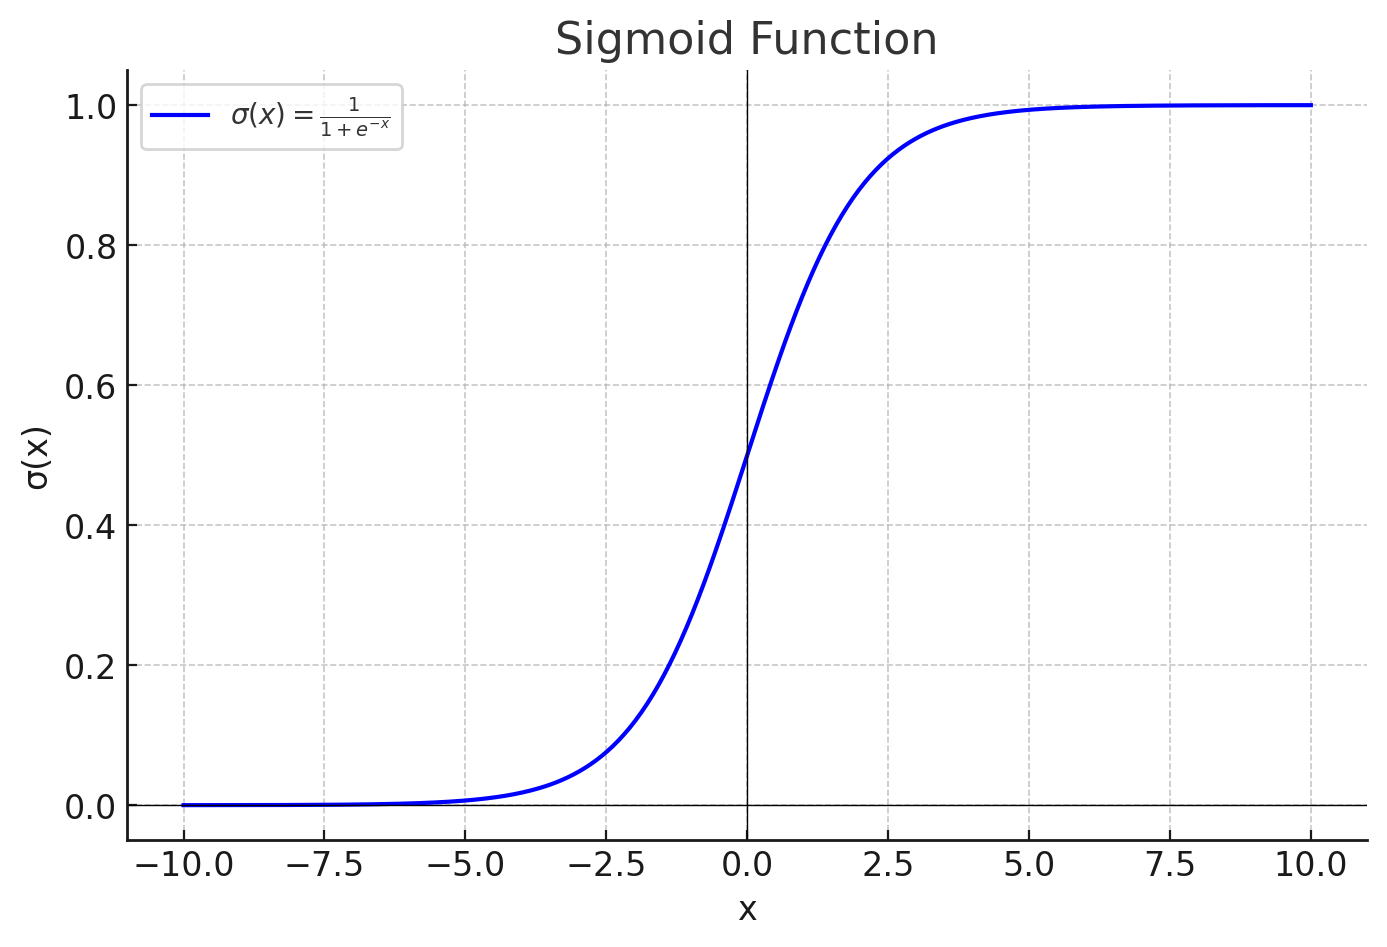
*   sigmoid_derivative(x)
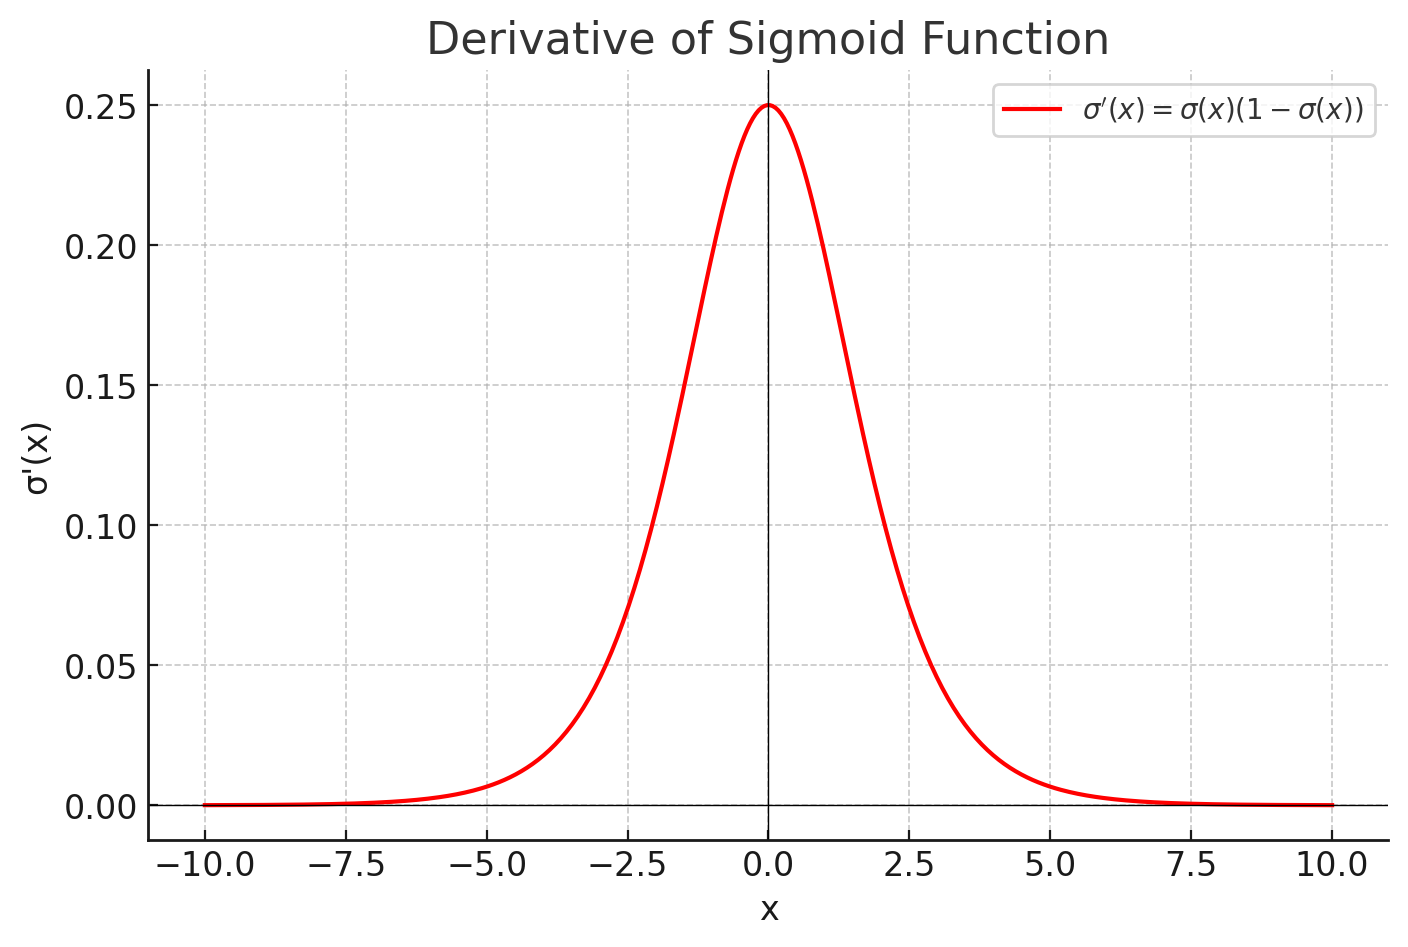

In [ ]:
def sigmoid(x):
  return 1 / (1 + np.exp(-x))

def sigmoid_derivative(x):
  return sigmoid(x) * (1 - sigmoid(x))

class NeuralNetwork:
  def __init__(self, input_size, hidden_size1, hidden_size2, hidden_size3, output_size):
    self.input_size = input_size
    self.hidden_size1 = hidden_size1
    self.hidden_size2 = hidden_size2
    self.hidden_size3 = hidden_size3
    self.output_size = output_size

    # 가중치 및 편향 초기화 (He 초기화 사용)
    # He 초기화 : 입력층에서 은닉층으로 전달되는 값들의 분산이 너무 커지거나 작아지는 것을 막기 위해,
    # 초기 가중치의 크기를 입력 노드 수에 맞춰 조정합니다.
    self.W1 = np.random.randn(self.input_size, self.hidden_size1) * np.sqrt(2 / self.input_size)
    self.B1 = np.zeros((1, self.hidden_size1))
    self.W2 = np.random.randn(self.hidden_size1, self.hidden_size2) * np.sqrt(2 / self.hidden_size1)
    self.B2 = np.zeros((1, self.hidden_size2))
    self.W3 = np.random.randn(self.hidden_size2, self.hidden_size3) * np.sqrt(2 / self.hidden_size2)
    self.B3 = np.zeros((1, self.hidden_size3))
    self.W4 = np.random.randn(self.hidden_size3, self.output_size) * np.sqrt(2 / self.hidden_size3)
    self.B4 = np.zeros((1, self.output_size))

    # 역전파 계산
    self.sW1 = np.zeros((self.input_size, self.hidden_size1))
    self.sB1 = np.zeros((1, self.hidden_size1))
    self.sW2 = np.zeros((self.hidden_size1, self.hidden_size2))
    self.sB2 = np.zeros((1, self.hidden_size2))
    self.sW3 = np.zeros((self.hidden_size2, self.hidden_size3))
    self.sB3 = np.zeros((1, self.hidden_size3))
    self.sW4 = np.zeros((self.hidden_size3, self.output_size))
    self.sB4 = np.zeros((1, self.output_size))

  def forward(self, X, Y=None):
    # 순전파 계산
    self.Z1 = np.dot(X, self.W1) + self.B1
    self.A1 = sigmoid(self.Z1)                                                  #
    self.Z2 = np.dot(self.A1, self.W2) + self.B2
    self.A2 = sigmoid(self.Z2)                                                  #
    self.Z3 = np.dot(self.A2, self.W3) + self.B3
    self.A3 = sigmoid(self.Z3)                                                  #
    self.Z4 = np.dot(self.A3, self.W4) + self.B4
    self.Y_hat = sigmoid(self.Z4)                                               #

    # Calculate error if Y is provided
    if Y is not None:
      error = np.mean((self.Y_hat - Y)**2)                                      # Mean Squared Error
    else:
      error = None

    return self.Y_hat, error                                                    # Return both Y_hat and error

  def backward(self, X, Y, learning_rate):
    # 역전파 계산
    # M x N 행열과 N x P 행열의 곱셈은 M x P 행열이 되며 앞의 행열의 열의(N) 개수와 뒤 행열의 행(N)의 개수가 같아야 한다.
                                                              # X shape (1, 200), Y shape (1, 25), Y_hat shape (1, 25)

    D4 = (self.Y_hat - Y) * sigmoid_derivative(self.Z4)       # D4 shape (1, 25), Y_hat shape (1, 25), Z4 shape (1, 25)
    dW4 = np.dot(self.A3.T, D4)                               # A3 shape (1, 50), dW4 shape (50, 25) = A3.T(50, 1) dot D4(1, 25)
    dB4 = np.sum(D4, axis=0, keepdims=True)                   # dB4 shape (1, 25)

    D3 = np.dot(D4, self.W4.T) * sigmoid_derivative(self.Z3)  # D3 shape (1, 50), D4 shape (1, 25), W4.T shape (25, 50), Z3 shape (1, 50)
    dW3 = np.dot(self.A2.T, D3)                               # A2 shape (1, 100), dW3 shape (100, 50) = A2.T(100, 1) dot D3(1, 50)
    dB3 = np.sum(D3, axis=0, keepdims=True)                   # dB3 shape (1, 50)

    D2 = np.dot(D3, self.W3.T) * sigmoid_derivative(self.Z2)  # D2 shape (1, 100), D3 shape (1, 50), W3.T shape (50, 100), Z2 shape (1, 100)
    dW2 = np.dot(self.A1.T, D2)                               # A1 shape (1, 200), dW2 shape (200, 100) = A1.T(200, 1) dot D2(1, 100)
    dB2 = np.sum(D2, axis=0, keepdims=True)                   # dB2 shape (1, 100)

    D1 = np.dot(D2, self.W2.T) * sigmoid_derivative(self.Z1)  # D1 shape (1, 200), D2 shape (1, 100), W2.T shape (100, 200), Z1 shape (1, 200)
    dW1 = np.dot(X.T, D1)                                     # X shape (1, 200), dW1 shape (200, 200) = X.T(200, 1) dot D1(1, 200)
    dB1 = np.sum(D1, axis=0, keepdims=True)                   # dB1 shape (1, 200)

    # 가중치 및 편향 업데이트
    self.W4 -= learning_rate * dW4
    self.B4 -= learning_rate * dB4
    self.W3 -= learning_rate * dW3
    self.B3 -= learning_rate * dB3
    self.W2 -= learning_rate * dW2
    self.B2 -= learning_rate * dB2
    self.W1 -= learning_rate * dW1
    self.B1 -= learning_rate * dB1

  def train(self, Xt, Yt, Xv, Yv, epochs, learning_rate):
    Terrors = []
    Verrors = []
    earlyStop = 0
    previousTError = float('inf')
    previousVError = float('inf')

    for i in range(epochs):
      Y_hat, tError = self.forward(Xt, Yt)                                      # Pass both X and y to forward
      Terrors.append(tError)
      self.backward(Xt, Yt, learning_rate)                                      # 가중치 W, 바이어스 b 업데이트

      _, vError = self.forward(Xv, Yv)                                          # 검증용 데이터 에러 계산
      Verrors.append(vError)
      print(f"Epoch {i+1}/{epochs}  Training Loss: {tError:.16f}  Validation Loss: {vError:.16f}")
      if vError < previousVError:
        earlyStop = 0
        previousVError = vError
        previousTError = tError
        # 학습 결과가 개선 되었으면 W, b 값 보관
        self.sW1 = self.W1; self.sB1 = self.B1
        self.sW2 = self.W2; self.sB2 = self.B2
        self.sW3 = self.W3; self.sB3 = self.B3
        self.sW4 = self.W4; self.sB4 = self.B4
      else:
        earlyStop += 1
        print(f"----- Early stopping {earlyStop}/{earlyStopCount}")
        if earlyStop >= earlyStopCount:
          print("Early stopping triggered")
          break

    # 보관된 학습 결과 복원
    self.W1 = self.sW1; self.B1 = self.sB1
    self.W2 = self.sW2; self.B2 = self.sB2
    self.W3 = self.sW3; self.B3 = self.sB3
    self.W4 = self.sW4; self.B4 = self.sB4

    return Terrors, Verrors, previousTError, previousVError

  def saveWeightBias(self, fileName):
    with open(fileName, 'wb') as f:
      pickle.dump(self.W1, f)
      pickle.dump(self.B1, f)
      pickle.dump(self.W2, f)
      pickle.dump(self.B2, f)
      pickle.dump(self.W3, f)
      pickle.dump(self.B3, f)
      pickle.dump(self.W4, f)
      pickle.dump(self.B4, f)


Xt (427, 200)
Yt (427, 25)
Xv (105, 200)
Yv (105, 25)
Epoch 1/5000  Training Loss: 0.3155498963567919  Validation Loss: 0.0389329768617305
Epoch 2/5000  Training Loss: 0.0395175730624567  Validation Loss: 0.0386787267417063
Epoch 3/5000  Training Loss: 0.0390061007586808  Validation Loss: 0.0386127169946550
Epoch 4/5000  Training Loss: 0.0389373495639256  Validation Loss: 0.0385439150745904
Epoch 5/5000  Training Loss: 0.0388708765842525  Validation Loss: 0.0384746759338360
Epoch 6/5000  Training Loss: 0.0388074221417679  Validation Loss: 0.0384079867544852
Epoch 7/5000  Training Loss: 0.0387489941571118  Validation Loss: 0.0383470275194385
Epoch 8/5000  Training Loss: 0.0386975624580439  Validation Loss: 0.0382938529582022
Epoch 9/5000  Training Loss: 0.0386536135687896  Validation Loss: 0.0382481304214217
Epoch 10/5000  Training Loss: 0.0386154518177227  Validation Loss: 0.0382078916495161
Epoch 11/5000  Training Loss: 0.0385806510725004  Validation Loss: 0.0381717361061353
Epoch 12/

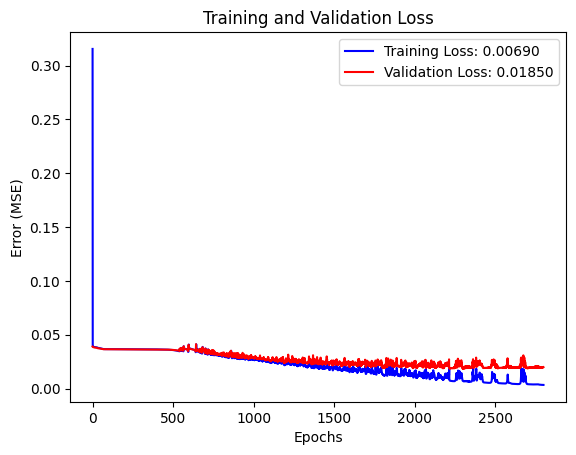

In [ ]:
# 신경망 객체 생성
nn = NeuralNetwork(200, 200, 100, 50, 25)  # 이미지 그래프 수의 값을 보전하기 위한 부분 , 25개중 확률 : 합쳐서 1인 값. 최적화값이 좋음(엔비디아cnn)

Xt, Yt = batchGen(x_train_Image, y_train_Angle, batchSize=len(x_train_Image))   # Train 데이터 준비
Xv, Yv = batchGen(x_valid_Image, y_valid_Angle, batchSize=len(x_valid_Image))   # Valid 데이터 준비

print('Xt', Xt.shape); print('Yt', Yt.shape); print('Xv', Xv.shape); print('Yv', Yv.shape)

Terrors, Verrors, terror, verror = nn.train(Xt, Yt, Xv, Yv, epochs, learning_rate)              # 학습

fn = f'_{project}_model.dnn'                                                    # 가중치 및 편향 파일 이름
nn.saveWeightBias(fn)                                                           # 가중치 및 편향 저장

plt.plot(Terrors, label = f'Training Loss: {terror:.5f}', color = 'b')
plt.plot(Verrors, label = f'Validation Loss: {verror:.5f}', color = 'r')
plt.legend()
plt.xlabel("Epochs")
plt.ylabel("Error (MSE)")
plt.title("Training and Validation Loss")
plt.show()


In [ ]:
X, Y = batchGen(x_test_Image, y_test_Angle, batchSize=len(x_test_Image))

predictions, _ = nn.forward(X)
rounded_predictions = np.round(predictions, 2)                                  # Round to 2 decimal places
print(rounded_predictions)
max_positions = np.argmax(predictions, axis=1)                                  # Find positions of maximum values along each row
print("최대값 위치:", max_positions)
predAngle = []
for i in max_positions:
  predAngle.append(int(i*7.2+3.6-90))                                           # int 로 변경(numpy -> python)후 리스트에 추가
print("예측 조향각:",predAngle)


[[0.   0.   0.   0.   0.   0.92 0.01 0.02 0.   0.   0.   0.   0.   0.01
  0.01 0.15 0.   0.   0.01 0.   0.   0.   0.   0.   0.  ]
 [0.   0.   0.   0.   0.   0.   0.   0.01 0.97 0.03 0.   0.   0.   0.
  0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.  ]
 [0.   0.   0.   0.   0.   0.   0.   0.02 0.   0.02 0.96 0.01 0.   0.
  0.02 0.   0.   0.09 0.   0.   0.   0.   0.   0.   0.  ]
 [0.   0.01 0.   0.   0.   0.   0.   0.   0.   0.01 0.   0.6  0.3  0.
  0.01 0.   0.   0.   0.   0.   0.   0.   0.   0.   0.  ]
 [0.   0.   0.   0.   0.   0.   0.   0.01 0.   0.   0.   0.01 0.   0.
  0.02 0.98 0.   0.   0.04 0.   0.   0.   0.   0.   0.  ]
 [0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.01
  0.03 0.8  0.05 0.   0.01 0.   0.   0.   0.   0.   0.  ]]
최대값 위치: [ 5  8 10 11 15 15]
예측 조향각: [-50, -28, -14, -7, 21, 21]


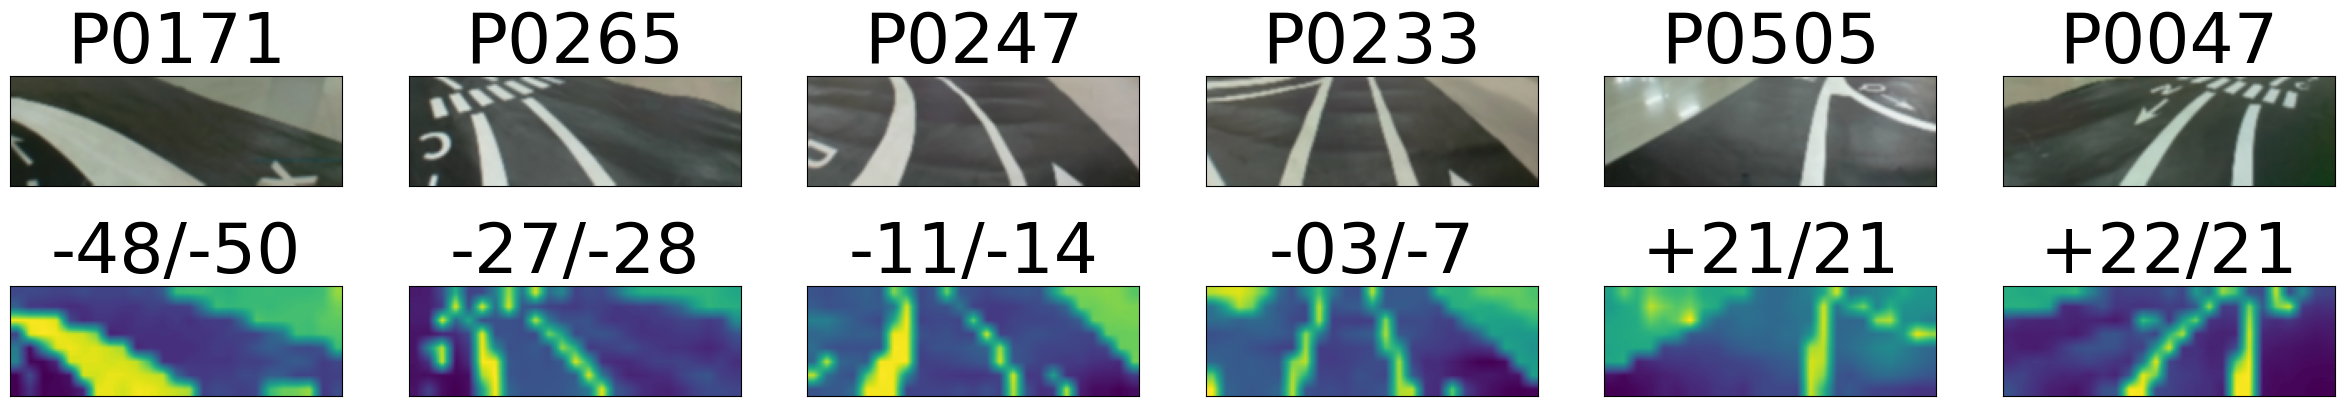

In [ ]:
# 테스트 이미지 라벨 조향각/예측 조향각 ------------------------------------
fig, axes = plt.subplots(2, len(x_test_Image), figsize=(30, 2+3))

for x, c in enumerate(x_test_Image):
  yuv_image = cv2.imread(f'{project}/{c}', cv2.IMREAD_UNCHANGED)                # 테스트 이미지 읽기
  bgr_image = cv2.cvtColor(yuv_image, cv2.COLOR_YUV2BGR)                        # YUV 이미지를 BGR 형식으로 변환
  rgb_image = cv2.cvtColor(bgr_image, cv2.COLOR_BGR2RGB)                        # MatPlot Lib 에서 표시되는 RGB 형식으로 변환
  axes[0,x].imshow(rgb_image)

  y_layer = yuv_image[:, :, 0]                                                  # Y 레이어만 추출
  resized_y = cv2.resize(y_layer, (25, 8))                                      # 이미지를 8 x 25 Pixle 로 축소, width, height 순서로 입력

  # Ensure resized_y has the correct data type for interpolation
  resized_y = resized_y.astype(np.uint8)

  bwLarge = cv2.resize(resized_y, (200, 66))                                    # 이미지를 200 x 66 Pixle 로 확대
  axes[1,x].imshow(bwLarge)

  t = x_test_Image[x][-7:-4] + '/' + str(predAngle[x])
  n = x_test_Image[x][-14:-9]

  axes[0,x].set_title(n, fontsize=50)
  axes[0,x].xaxis.set_ticks([])
  axes[0,x].yaxis.set_ticks([])
  axes[1,x].set_title(t, fontsize=50)
  axes[1,x].xaxis.set_ticks([])
  axes[1,x].yaxis.set_ticks([])
plt.show()
